In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn import set_config

from sksurv.svm import FastSurvivalSVM
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Survival Support Vector Machine

- ranking objective: learns to assign higher risk scores to patients with shorter survival
- regularisation parameter `alpha` controls bias-variance trade-off (smaller = more regularisation)
- predictions are risk scores  higher value = higher relapse risk

## Preparing Data for Fitting

In [4]:
# load pre-processed datasets
train_data    = pd.read_csv('../../datasets/csv_files/ml_datasets/train_data.csv')
test_data_one   = pd.read_csv('../../datasets/csv_files/ml_datasets/test_data_one.csv')
test_data_two   = pd.read_csv('../../datasets/csv_files/ml_datasets/test_data_two.csv')
test_data_three = pd.read_csv('../../datasets/csv_files/ml_datasets/test_data_three.csv')

In [5]:
# define X & y for all datasets
X_train = train_data.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
y_train = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', train_data)

X_test_one = test_data_one.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_one = X_test_one[X_train.columns]
y_test_one = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_one)

X_test_two = test_data_two.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_two = X_test_two[X_train.columns]
y_test_two = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_two)

X_test_three = test_data_three.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_three = X_test_three[X_train.columns]
y_test_three = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_three)

## Fit Initial Model

In [6]:
# ranking objective (rank_ratio=1.0): higher predicted value = higher risk
svm_init = FastSurvivalSVM(rank_ratio=1.0, max_iter=1000, tol=1e-5, random_state=42)
svm_init.fit(X_train, y_train)

init_train_ci = svm_init.score(X_train, y_train)
print(f'Initial model  Train C-index: {init_train_ci:.5f}')

Initial model  Train C-index: 1.00000


In [7]:
# 5-fold cross-validation on the initial model
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(svm_init, X_train, y_train, cv=5, n_jobs=-1)
print(f'5-fold CV C-index: {cv_scores.mean():.5f} Â± {cv_scores.std():.5f}')

5-fold CV C-index: 0.65725 Â± 0.08186


## Tune Alpha (Regularisation) with GridSearchCV

`alpha` is the inverse regularisation strength  smaller values impose stronger regularisation and reduce overfitting.

In [8]:
def score_survival_model(model, X, y):
    """Concordance index scorer compatible with GridSearchCV."""
    pred = model.predict(X)
    result = concordance_index_censored(y['relapse_free_event'], y['relapse_free_time'], pred)
    return result[0]

param_grid = {'alpha': [2.0 ** v for v in range(-10, 11, 2)]}

cv_strategy = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

gcv = GridSearchCV(
    FastSurvivalSVM(rank_ratio=1.0, max_iter=1000, tol=1e-5, random_state=42),
    param_grid,
    scoring=score_survival_model,
    cv=cv_strategy,
    n_jobs=-1,
    refit=False
)
gcv.fit(X_train, y_train)

print(f'Best CV C-index : {gcv.best_score_:.5f}')
print(f'Best alpha      : {gcv.best_params_}')

Best CV C-index : 0.67089
Best alpha      : {'alpha': 0.0009765625}


Saved: svm_alpha_tuning.png


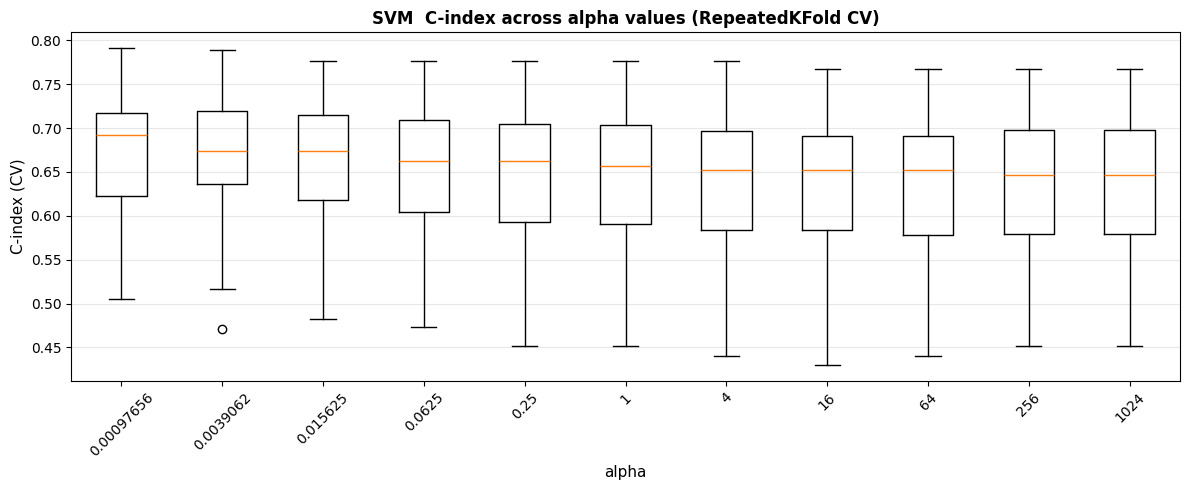

In [9]:
# box plot of CV scores across alpha values
import pandas as _pd

cv_rows = []
for i, params in enumerate(gcv.cv_results_['params']):
    label = f"{params['alpha']:.5g}"
    n_splits = gcv.cv.cvargs['n_splits']
    n_repeats = gcv.cv.n_repeats
    for j in range(n_splits * n_repeats):
        score = gcv.cv_results_.get(f'split{j}_test_score', [None] * len(gcv.cv_results_['params']))[i]
        if score is not None:
            cv_rows.append({'alpha': label, 'C-index': score})

cv_df = _pd.DataFrame(cv_rows)
order = [f"{p['alpha']:.5g}" for p in gcv.cv_results_['params']]

fig, ax = plt.subplots(figsize=(12, 5))
groups = [cv_df.loc[cv_df['alpha'] == a, 'C-index'].values for a in order]
ax.boxplot(groups, labels=order)
ax.set_xlabel('alpha', fontsize=11)
ax.set_ylabel('C-index (CV)', fontsize=11)
ax.set_title('SVM  C-index across alpha values (RepeatedKFold CV)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../../visuals/svm_alpha_tuning.png', dpi=150, bbox_inches='tight')
print('Saved: svm_alpha_tuning.png')
plt.show()

## Train Final Regularised Model

In [10]:
model_path = '../../models/svm.joblib'

if os.path.exists(model_path):
    print('Loading saved SVM model...')
    svm = joblib.load(model_path)
    print('Loaded.')
else:
    print('Training final SVM with best alpha...')
    svm = FastSurvivalSVM(
        rank_ratio=1.0,
        max_iter=1000,
        tol=1e-5,
        random_state=42,
        **gcv.best_params_
    )
    svm.fit(X_train, y_train)
    joblib.dump(svm, model_path)
    print('Trained and saved.')

Loading saved SVM model...
Loaded.


## C-Index Evaluation

In [11]:
c_index_train = svm.score(X_train, y_train)
c_index_test_one   = svm.score(X_test_one,   y_test_one)
c_index_test_two   = svm.score(X_test_two,   y_test_two)
c_index_test_three = svm.score(X_test_three, y_test_three)

print(f'Train C-index  : {c_index_train:.5f}')
print(f'Test 1 C-index : {c_index_test_one:.5f}')
print(f'Test 2 C-index : {c_index_test_two:.5f}')
print(f'Test 3 C-index : {c_index_test_three:.5f}')

Train C-index  : 0.97296
Test 1 C-index : 0.57894
Test 2 C-index : 0.59660
Test 3 C-index : 0.63324


## Permutation Importance

In [12]:
perm_path = '../../models/svm_perm_importance.csv'

if os.path.exists(perm_path):
    print('Loading cached permutation importance...')
    perm_df = pd.read_csv(perm_path)
else:
    print('Computing permutation importance (n_repeats=5  may take several minutes)...')
    result = permutation_importance(
        svm, X_train, y_train,
        n_repeats=5, random_state=42, n_jobs=-1
    )
    perm_df = pd.DataFrame({
        'gene':            X_train.columns,
        'importance_mean': result.importances_mean,
        'importance_std':  result.importances_std,
    }).sort_values('importance_mean', ascending=False).reset_index(drop=True)
    perm_df.to_csv(perm_path, index=False)
    print('Done. Cached to svm_perm_importance.csv')

print('\nTop 20 features by permutation importance:')
print(perm_df.head(20).to_string(index=False))

Loading cached permutation importance...

Top 20 features by permutation importance:
    gene  importance_mean  importance_std
   S100P         0.053201        0.005445
   CXCL9         0.028532        0.002768
   VTCN1         0.027980        0.005318
     GRP         0.026490        0.002629
 S100A14         0.022572        0.004301
  S100A7         0.022572        0.003215
 SLC39A6         0.021523        0.001329
  ZBTB16         0.013907        0.000594
   KCNJ8         0.013300        0.003675
    PLK2         0.011976        0.001994
     LTF         0.011810        0.003005
    SDC1         0.011810        0.002097
 CEACAM6         0.011700        0.001325
    CD36         0.011203        0.003081
   UBE2S         0.010541        0.003417
  UBE2E3         0.010486        0.001719
    CCL2         0.010430        0.001495
    MICB         0.010210        0.001144
   PTGDS         0.010210        0.001418
RAP1GAP2         0.009879        0.001766


Saved: svm_permutation_importance.png


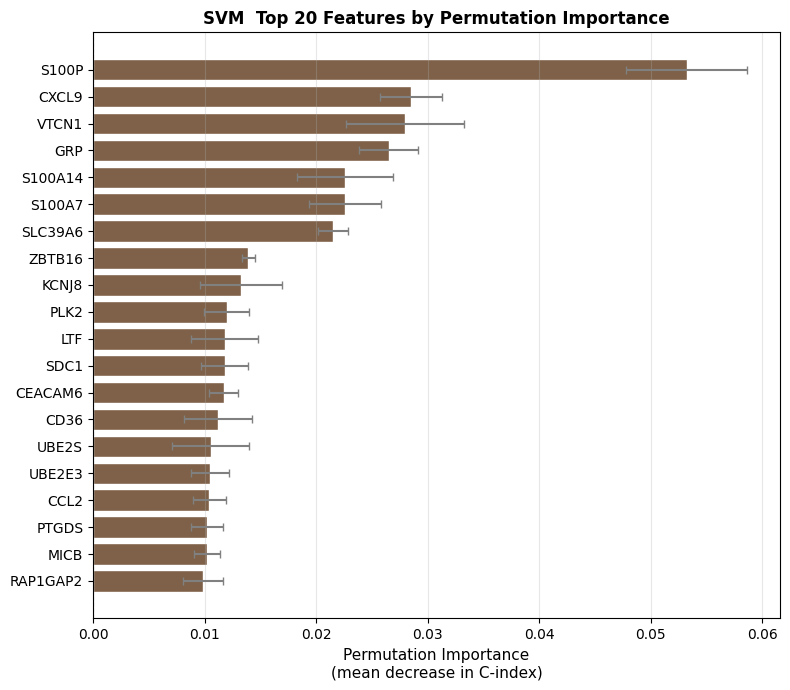

In [13]:
# bar chart: top 20 genes
top20 = perm_df.head(20).sort_values('importance_mean')

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20['gene'], top20['importance_mean'],
        xerr=top20['importance_std'], color='#7E6148',
        error_kw=dict(ecolor='grey', capsize=3), edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Permutation Importance\n(mean decrease in C-index)', fontsize=11)
ax.set_title('SVM  Top 20 Features by Permutation Importance', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../../visuals/svm_permutation_importance.png', dpi=150, bbox_inches='tight')
print('Saved: svm_permutation_importance.png')
plt.show()

## SVM Gene Signature

In [14]:
from scipy.stats import spearmanr

# Aggressive / compact signature: top 8 genes with positive permutation importance
sig_df = perm_df[perm_df['importance_mean'] > 0].head(8).copy()
if len(sig_df) < 3:
    sig_df = perm_df.head(8).copy()

sig_genes = sig_df['gene'].tolist()

# Risk score: higher predicted value = higher relapse risk (ranking objective)
svm_risk_train = svm.predict(X_train)

directions = []
for gene in sig_genes:
    r, p = spearmanr(X_train[gene], svm_risk_train)
    directions.append({
        'gene':       gene,
        'importance': round(sig_df.loc[sig_df['gene'] == gene, 'importance_mean'].values[0], 5),
        'spearman_r': round(r, 4),
        'p_value':    round(p, 4),
        'role':       'danger' if r > 0 else 'protective',
    })

sig_genes_df = pd.DataFrame(directions)

# Paper comparison
PAPER_SIGNATURE = ['TSLP', 'BIRC5', 'S100B', 'MDK', 'S100P', 'RARRES3', 'BLNK', 'ACO1']
in_paper  = [g for g in sig_genes if g in PAPER_SIGNATURE]
not_paper = [g for g in sig_genes if g not in PAPER_SIGNATURE]
missing   = [g for g in PAPER_SIGNATURE if g not in sig_genes]

print('=' * 55)
print(f'  SVM IMMUNE RISK SIGNATURE  ({len(sig_genes)} genes)')
print('=' * 55)
for _, row in sig_genes_df.iterrows():
    marker = '  [paper]' if row['gene'] in PAPER_SIGNATURE else ''
    print(f"  {row['gene']:<12}  imp={row['importance']:.5f}  r={row['spearman_r']:+.3f}  {row['role']}{marker}")

print()
print(f'Paper overlap : {len(in_paper)}/{len(PAPER_SIGNATURE)} {in_paper}')
print(f'Novel genes   : {not_paper}')
print(f'Paper genes missing: {missing}')

  SVM IMMUNE RISK SIGNATURE  (8 genes)
  S100P         imp=0.05320  r=+0.396  danger  [paper]
  CXCL9         imp=0.02853  r=-0.070  protective
  VTCN1         imp=0.02798  r=+0.165  danger
  GRP           imp=0.02649  r=-0.040  protective
  S100A14       imp=0.02257  r=+0.112  danger
  S100A7        imp=0.02257  r=+0.093  danger
  SLC39A6       imp=0.02152  r=-0.236  protective
  ZBTB16        imp=0.01391  r=+0.070  danger

Paper overlap : 1/8 ['S100P']
Novel genes   : ['CXCL9', 'VTCN1', 'GRP', 'S100A14', 'S100A7', 'SLC39A6', 'ZBTB16']
Paper genes missing: ['TSLP', 'BIRC5', 'S100B', 'MDK', 'RARRES3', 'BLNK', 'ACO1']


## Risk Score & Patient Stratification

In [15]:
svm_risk_test_one   = svm.predict(X_test_one)
svm_risk_test_two   = svm.predict(X_test_two)
svm_risk_test_three = svm.predict(X_test_three)

print('Risk score summaries (SVM ranking score):')
for name, scores in [('Train',  svm_risk_train),
                     ('Test 1', svm_risk_test_one),
                     ('Test 2', svm_risk_test_two),
                     ('Test 3', svm_risk_test_three)]:
    print(f'  {name:8s} n={len(scores):3d}  mean={scores.mean():.3f}  '
          f'median={np.median(scores):.3f}  min={scores.min():.3f}  max={scores.max():.3f}')

Risk score summaries (SVM ranking score):
  Train    n=104  mean=-2.261  median=-2.420  min=-3.484  max=-0.675
  Test 1   n=244  mean=-2.380  median=-2.365  min=-4.272  max=-0.412
  Test 2   n= 88  mean=-2.094  median=-2.082  min=-3.302  max=-0.817
  Test 3   n=117  mean=-3.240  median=-3.310  min=-4.745  max=-1.824


Training median risk score (cutoff): -2.4196
Train     high= 52  low= 52  log-rank p=0.0000
Test 1    high=132  low=112  log-rank p=0.0056
Test 2    high= 67  low= 21  log-rank p=0.1280
Test 3    high= 10  low=107  log-rank p=0.1737

Saved: svm_km_stratification.png


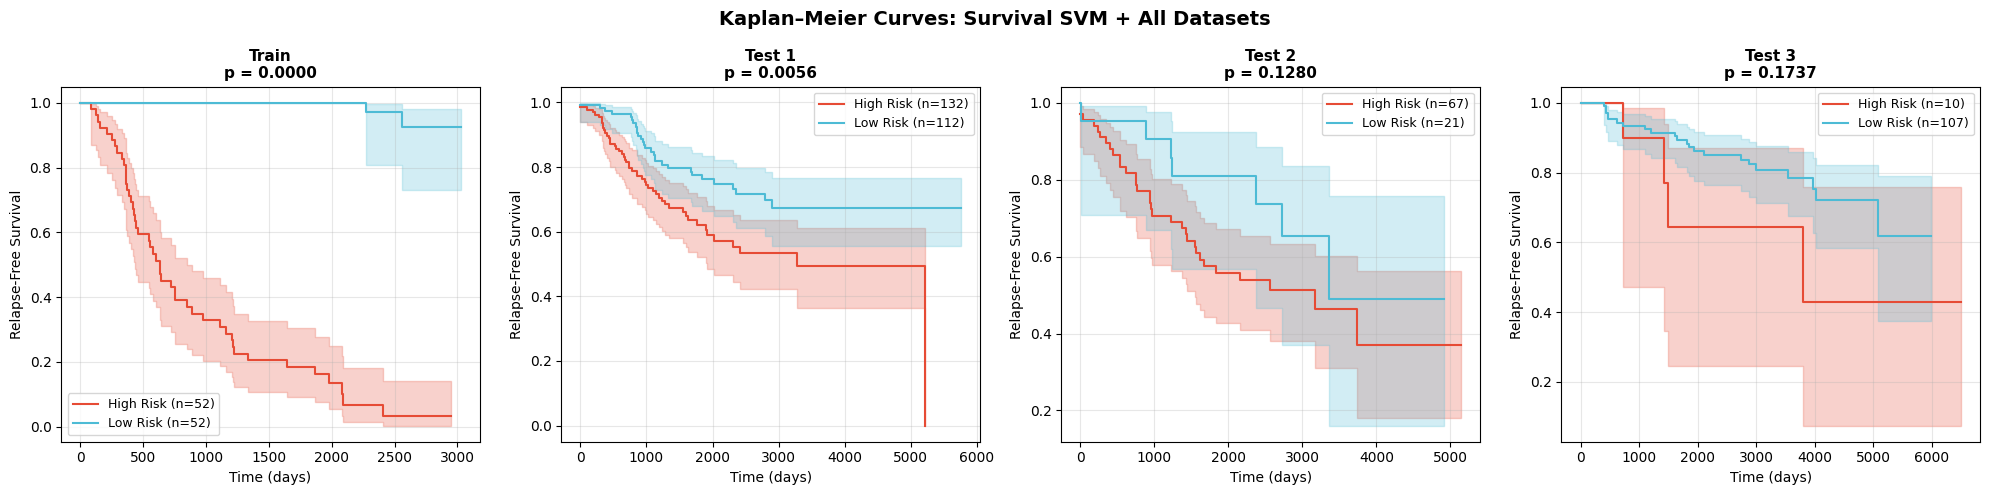

In [16]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

train_median = np.median(svm_risk_train)
print(f'Training median risk score (cutoff): {train_median:.4f}')

def stratify(scores):
    return np.where(scores >= train_median, 'High Risk', 'Low Risk')

def plot_km(df, scores, title, ax):
    groups = stratify(scores)
    tmp = pd.DataFrame({
        'time':  pd.to_numeric(df['relapse_free_time'],  errors='coerce').astype(float),
        'event': pd.to_numeric(df['relapse_free_event'], errors='coerce').astype(bool),
        'group': groups,
    }).dropna(subset=['time', 'event'])

    kmf = KaplanMeierFitter()
    colors = {'High Risk': '#E64B35', 'Low Risk': '#4DBBD5'}
    for group, color in colors.items():
        mask = tmp['group'] == group
        if mask.sum() == 0:
            continue
        kmf.fit(tmp.loc[mask, 'time'], tmp.loc[mask, 'event'],
                label=f'{group} (n={mask.sum()})')
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

    high = tmp['group'] == 'High Risk'
    low  = tmp['group'] == 'Low Risk'
    p = logrank_test(tmp.loc[high, 'time'], tmp.loc[low, 'time'],
                     tmp.loc[high, 'event'], tmp.loc[low, 'event']).p_value

    ax.set_title(f'{title}\np = {p:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Relapse-Free Survival')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    return p

svm_groups_train = stratify(svm_risk_train)

datasets = [
    ('Train',  train_data,      svm_risk_train),
    ('Test 1', test_data_one,   svm_risk_test_one),
    ('Test 2', test_data_two,   svm_risk_test_two),
    ('Test 3', test_data_three, svm_risk_test_three),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, df, scores) in zip(axes, datasets):
    groups = stratify(scores)
    p = plot_km(df, scores, name, ax)
    print(f"{name:8s}  high={np.sum(groups=='High Risk'):3d}  "
          f"low={np.sum(groups=='Low Risk'):3d}  log-rank p={p:.4f}")

plt.suptitle("Kaplan–Meier Curves: Survival SVM + All Datasets", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig('../../visuals/svm_km_stratification.png', dpi=150, bbox_inches='tight')
print('\nSaved: svm_km_stratification.png')
plt.show()

## Gene Signature Visualizations

Saved: svm_gene_signature_heatmap.png


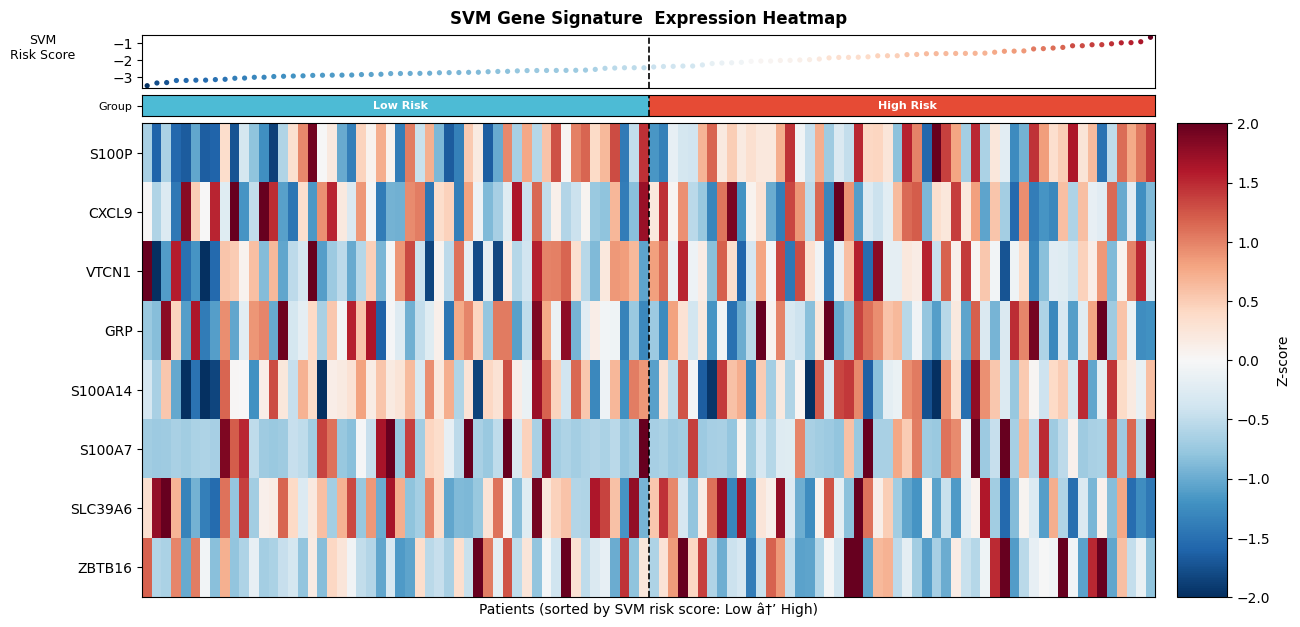

In [17]:
from scipy.stats import zscore
from matplotlib.colors import ListedColormap

# Sort patients by SVM risk score (low â†’ high)
sort_idx      = np.argsort(svm_risk_train)
sorted_scores = svm_risk_train[sort_idx]
sorted_groups = svm_groups_train[sort_idx]

expr_mat   = train_data[sig_genes].values[sort_idx].T
expr_z     = zscore(expr_mat, axis=1)
n_patients = expr_mat.shape[1]
split      = int(np.sum(sorted_groups == 'Low Risk'))

fig = plt.figure(figsize=(14, 2.5 + len(sig_genes) * 0.6))
gs  = fig.add_gridspec(3, 2,
                       height_ratios=[0.9, 0.35, len(sig_genes)],
                       width_ratios=[20, 1],
                       hspace=0.04, wspace=0.04)

ax_rs = fig.add_subplot(gs[0, 0])
ax_rs.scatter(range(n_patients), sorted_scores,
              c=sorted_scores, cmap='RdBu_r', s=14, linewidths=0)
ax_rs.axvline(split - 0.5, color='black', lw=1.2, ls='--')
ax_rs.set_ylabel('SVM\nRisk Score', fontsize=9, rotation=0, labelpad=50)
ax_rs.set_xlim(-0.5, n_patients - 0.5)
ax_rs.set_xticks([])
ax_rs.set_title('SVM Gene Signature  Expression Heatmap', fontsize=12, fontweight='bold', pad=8)

ax_grp = fig.add_subplot(gs[1, 0], sharex=ax_rs)
ax_grp.imshow(np.where(sorted_groups == 'High Risk', 1, 0).reshape(1, -1),
              aspect='auto', cmap=ListedColormap(['#4DBBD5', '#E64B35']), vmin=0, vmax=1)
ax_grp.set_yticks([0])
ax_grp.set_yticklabels(['Group'], fontsize=8)
ax_grp.set_xticks([])
ax_grp.axvline(split - 0.5, color='black', lw=1.2, ls='--')
ax_grp.text(split / 2, 0, 'Low Risk',  ha='center', va='center', fontsize=8, color='white', fontweight='bold')
ax_grp.text(split + (n_patients - split) / 2, 0, 'High Risk', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax_hm = fig.add_subplot(gs[2, 0], sharex=ax_rs)
im = ax_hm.imshow(expr_z, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
ax_hm.set_yticks(range(len(sig_genes)))
ax_hm.set_yticklabels(sig_genes, fontsize=10)
ax_hm.set_xlabel('Patients (sorted by SVM risk score: Low â†’ High)', fontsize=10)
ax_hm.axvline(split - 0.5, color='black', lw=1.2, ls='--')

plt.colorbar(im, cax=fig.add_subplot(gs[2, 1]), label='Z-score')
plt.savefig('../../visuals/svm_gene_signature_heatmap.png', dpi=150, bbox_inches='tight')
print('Saved: svm_gene_signature_heatmap.png')
plt.show()

Saved: svm_gene_signature_expression.png


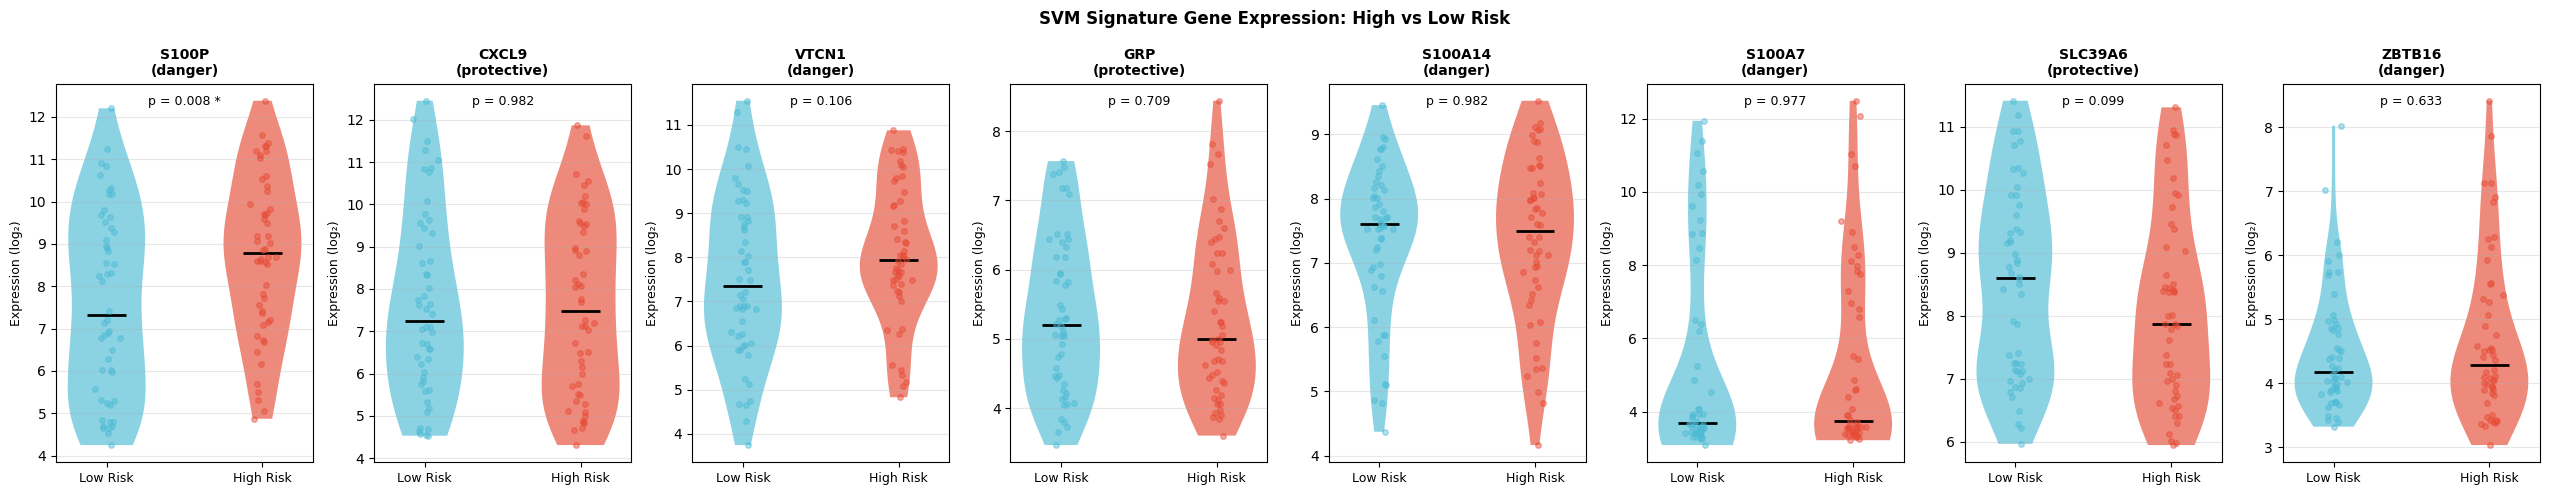

In [18]:
from scipy.stats import mannwhitneyu

mask_low  = (svm_groups_train == 'Low Risk')
mask_high = (svm_groups_train == 'High Risk')

n_genes = len(sig_genes)
fig, axes = plt.subplots(1, n_genes, figsize=(max(6, 3.2 * n_genes), 5))
if n_genes == 1:
    axes = [axes]

for ax, gene in zip(axes, sig_genes):
    data_low  = train_data[gene].values[mask_low]
    data_high = train_data[gene].values[mask_high]

    if len(data_low) < 2 or len(data_high) < 2:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes, fontsize=9)
        ax.set_title(gene, fontsize=10, fontweight='bold')
        continue

    parts = ax.violinplot([data_low, data_high], positions=[0, 1],
                          showmedians=True, showextrema=False)
    for pc, color in zip(parts['bodies'], ['#4DBBD5', '#E64B35']):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    for pos, data, color in [(0, data_low, '#4DBBD5'), (1, data_high, '#E64B35')]:
        jitter = np.random.default_rng(42).normal(0, 0.04, len(data))
        ax.scatter(pos + jitter, data, alpha=0.45, s=16, color=color, zorder=3)

    _, p = mannwhitneyu(data_low, data_high, alternative='two-sided')
    role = sig_genes_df.loc[sig_genes_df['gene'] == gene, 'role'].values[0]
    ax.text(0.5, 0.97, f'p = {p:.3f}' + (' *' if p < 0.05 else ''),
            transform=ax.transAxes, ha='center', va='top', fontsize=9)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Low Risk', 'High Risk'], fontsize=9)
    ax.set_title(f'{gene}\n({role})', fontsize=10, fontweight='bold')
    ax.set_ylabel('Expression (log\u2082)', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('SVM Signature Gene Expression: High vs Low Risk', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../visuals/svm_gene_signature_expression.png', dpi=150, bbox_inches='tight')
print('Saved: svm_gene_signature_expression.png')
plt.show()

Saved: svm_gene_signature_correlation.png


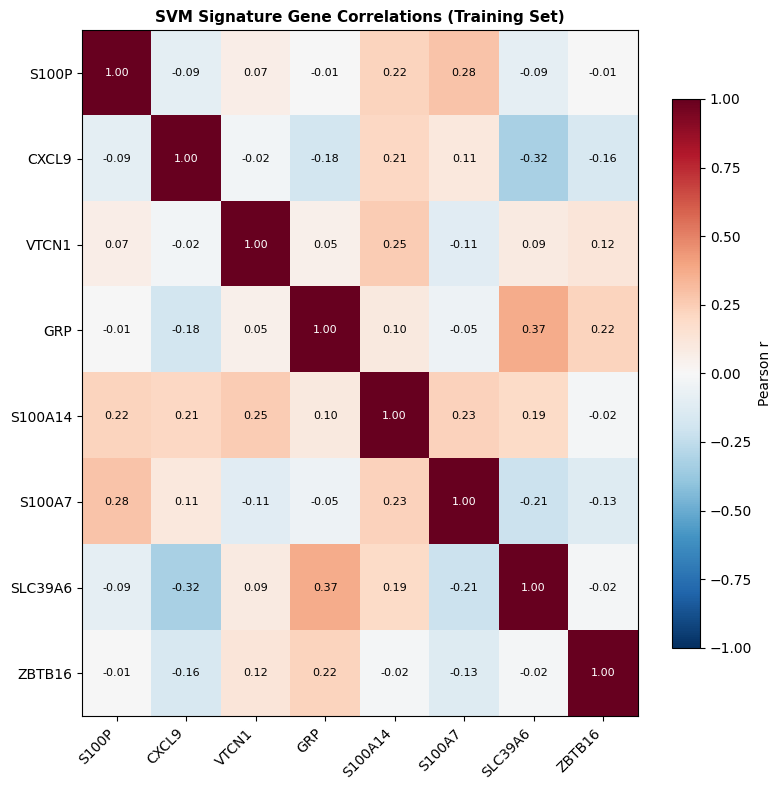

In [19]:
# correlation heatmap between signature genes
if len(sig_genes) > 1:
    corr = train_data[sig_genes].corr(method='pearson')

    fig, ax = plt.subplots(figsize=(max(4, len(sig_genes)), max(3.5, len(sig_genes))))
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(sig_genes)))
    ax.set_yticks(range(len(sig_genes)))
    ax.set_xticklabels(sig_genes, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(sig_genes, fontsize=10)

    for i in range(len(sig_genes)):
        for j in range(len(sig_genes)):
            v = corr.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(v) > 0.6 else 'black')

    plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
    ax.set_title('SVM Signature Gene Correlations (Training Set)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../../visuals/svm_gene_signature_correlation.png', dpi=150, bbox_inches='tight')
    print('Saved: svm_gene_signature_correlation.png')
    plt.show()
else:
    print('Only 1 gene  correlation heatmap skipped.')

## Save Model

In [20]:
os.makedirs('../../models', exist_ok=True)
joblib.dump(svm, '../../models/svm.joblib')

['../../models/svm.joblib']

## Model Performance Comparison

C-index across RSF, Gradient Boosting, and SVM on the same test datasets.

In [21]:
# load RSF v2 and GB models for comparison
rsf = joblib.load('../../models/rsf_v2.joblib')
gb  = joblib.load('../../models/gbs_cox.joblib')

# GB was trained on ml_datasets datasets  load those separately
gb_train = pd.read_csv('../../datasets/csv_files/ml_datasets/train_data.csv')
gb_test1 = pd.read_csv('../../datasets/csv_files/ml_datasets/test_data_one.csv')
gb_test2 = pd.read_csv('../../datasets/csv_files/ml_datasets/test_data_two.csv')
gb_test3 = pd.read_csv('../../datasets/csv_files/ml_datasets/test_data_three.csv')

def make_Xy(df, feature_cols):
    X = df[feature_cols]
    y = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', df)
    return X, y

gb_feat = list(gb_train.columns[3:])
Xg_tr, yg_tr = make_Xy(gb_train, gb_feat)
Xg_t1, yg_t1 = make_Xy(gb_test1, gb_feat)
Xg_t2, yg_t2 = make_Xy(gb_test2, gb_feat)
Xg_t3, yg_t3 = make_Xy(gb_test3, gb_feat)

scores = {
    'RSF': {
        'Train':  rsf.score(X_train,      y_train),
        'Test 1': rsf.score(X_test_one,   y_test_one),
        'Test 2': rsf.score(X_test_two,   y_test_two),
        'Test 3': rsf.score(X_test_three, y_test_three),
    },
    'Gradient\nBoosting': {
        'Train':  gb.score(Xg_tr, yg_tr),
        'Test 1': gb.score(Xg_t1[gb_feat], yg_t1),
        'Test 2': gb.score(Xg_t2[gb_feat], yg_t2),
        'Test 3': gb.score(Xg_t3[gb_feat], yg_t3),
    },
    'SVM': {
        'Train':  c_index_train,
        'Test 1': c_index_test_one,
        'Test 2': c_index_test_two,
        'Test 3': c_index_test_three,
    },
}

# print table
datasets_order = ['Train', 'Test 1', 'Test 2', 'Test 3']
models_order   = list(scores.keys())
print(f"{'':15s}" + ''.join(f"{m:>18s}" for m in models_order))
for ds in datasets_order:
    row = f'{ds:<15s}'
    for m in models_order:
        row += f"{scores[m][ds]:>18.5f}"
    print(row)

                              RSF Gradient
Boosting               SVM
Train                     0.79663           0.82064           0.97296
Test 1                    0.63340           0.61312           0.57894
Test 2                    0.57877           0.47410           0.59660
Test 3                    0.69821           0.60970           0.63324


Saved: model_comparison.png


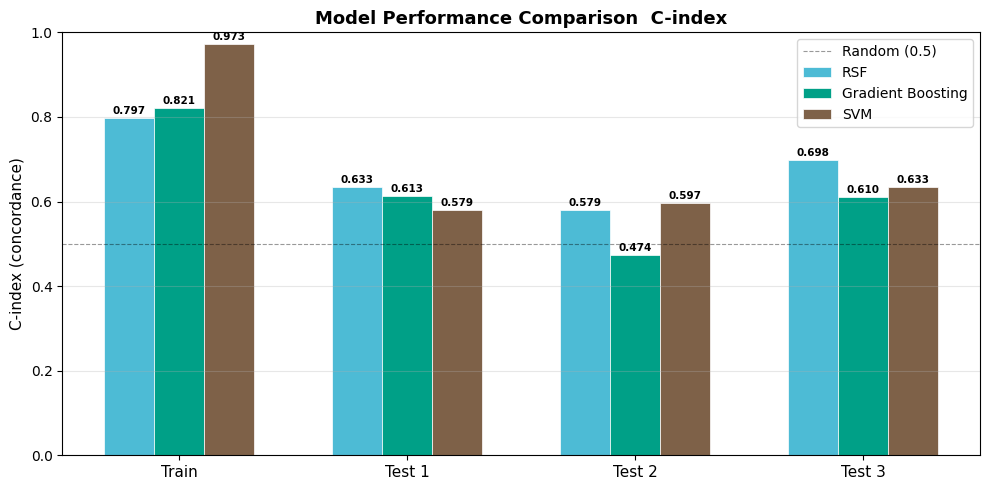

In [22]:
# grouped bar chart
datasets_order = ['Train', 'Test 1', 'Test 2', 'Test 3']
models_order   = list(scores.keys())
model_colors   = {'RSF': '#4DBBD5', 'Gradient\nBoosting': '#00A087', 'SVM': '#7E6148'}

x      = np.arange(len(datasets_order))
n_mdl  = len(models_order)
width  = 0.22
offsets = np.linspace(-(n_mdl - 1) / 2, (n_mdl - 1) / 2, n_mdl) * width

fig, ax = plt.subplots(figsize=(10, 5))

for model, offset in zip(models_order, offsets):
    vals = [scores[model][ds] for ds in datasets_order]
    bars = ax.bar(x + offset, vals, width, label=model.replace('\n', ' '),
                  color=model_colors[model], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.axhline(0.5, color='black', linewidth=0.8, linestyle='--', alpha=0.4, label='Random (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(datasets_order, fontsize=11)
ax.set_ylabel('C-index (concordance)', fontsize=11)
ax.set_title('Model Performance Comparison  C-index', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../../visuals/model_comparison.png', dpi=150, bbox_inches='tight')
print('Saved: model_comparison.png')
plt.show()